In [1]:
%load_ext cython

In [16]:
# Cell 1: OPTIMIZED LLM Agent (Using Your Available Models)
import requests
import json
import time
import re
from typing import Dict, List, Optional, Tuple

# --- CONFIGURATION FOR YOUR SETUP ---
OLLAMA_API_URL = "http://localhost:11434/api/generate"
LLM_MODEL = "llama3:8b"  # 🔥 Use your faster 8b model instead of latest

class OptimizedLLMAgent:
    """Optimized LLM agent with caching and domain-aware prompting."""

    def __init__(self, model_name=LLM_MODEL, api_url=OLLAMA_API_URL):
        self.model_name = model_name
        self.api_url = api_url
        self.solution_cache = {}  # Cache for similar solutions
        print(f"🚀 Optimized LLM Agent initialized for model: {self.model_name}")

    def _call_ollama(self, prompt, temperature=0.3):
        """Fast API call with aggressive optimization for your setup."""
        payload = {
            "model": self.model_name,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": temperature,
                "num_predict": 80,      # 🔥 Very short responses
                "top_k": 10,
                "top_p": 0.8,
                "repeat_penalty": 1.1,
                "num_ctx": 1024,        # Smaller context for speed
                "num_thread": 8         # Use multiple threads
            }
        }
        try:
            response = requests.post(self.api_url, json=payload, timeout=20)  # Short timeout
            response.raise_for_status()
            return response.json()['response']
        except requests.exceptions.RequestException as e:
            print(f"⚠️  LLM API Error: {e}")
            return None

    def _create_ultra_focused_prompt(self, current_solution_data, problem_data):
        """Ultra-focused prompt for maximum speed and relevance."""
        current_items = current_solution_data['items']
        num_items = problem_data['num_items']
        
        # Calculate target size (heuristic for knapsack)
        target_size = max(8, min(len(current_items) + 5, 25))
        
        # Ultra-short, focused prompt
        prompt = f"""Knapsack optimization. Current solution: {len(current_items)} items.
Generate {target_size} item indices (0-{num_items-1}) for better profit.
JSON only: {{"items": [1,5,9,12,15,20,25,30]}}"""
        
        return prompt

    def generate_smart_neighbor(self, current_solution_data, problem_data):
        """Generate optimized neighbor solution with caching."""
        # Simple cache key
        cache_key = f"{len(current_solution_data['items'])}_{problem_data['num_items']}"
        
        # Check cache first
        if cache_key in self.solution_cache:
            cached_solution = self.solution_cache[cache_key]
            # Add some randomization to cached solutions
            import random
            if len(cached_solution) > 5:
                # Modify 2-3 items randomly
                modified = cached_solution.copy()
                for _ in range(min(3, len(modified)//3)):
                    idx = random.randint(0, len(modified)-1)
                    modified[idx] = random.randint(0, problem_data['num_items']-1)
                print(f"  -> 🎯 Using modified cached solution ({len(modified)} items)")
                return modified

        # Generate new solution
        prompt = self._create_ultra_focused_prompt(current_solution_data, problem_data)
        
        print("  -> ⚡ Calling Fast LLM (llama3:8b)...")
        start_time = time.time()
        
        response = self._call_ollama(prompt, temperature=0.2)
        
        end_time = time.time()
        
        if not response:
            print(f"  -> ❌ LLM failed after {end_time - start_time:.2f}s")
            return None

        # Parse response
        parsed_data = self._parse_json_from_response(response)
        if parsed_data and "items" in parsed_data and isinstance(parsed_data["items"], list):
            new_solution = parsed_data["items"]
            
            # Validate solution
            valid_items = [item for item in new_solution if isinstance(item, int) and 0 <= item < problem_data['num_items']]
            
            if len(valid_items) >= 5:  # Minimum 5 items
                # Cache the solution
                self.solution_cache[cache_key] = valid_items
                print(f"  -> ✅ Generated {len(valid_items)} items in {end_time - start_time:.2f}s (cached)")
                return valid_items
        
        print(f"  -> ❌ Invalid solution after {end_time - start_time:.2f}s")
        return None

    def _parse_json_from_response(self, response_text):
        """Extract JSON from LLM response."""
        # First try to find complete JSON object
        match = re.search(r'\{[^}]*"items"[^}]*\}', response_text)
        if match:
            json_string = match.group(0)
            try:
                return json.loads(json_string)
            except json.JSONDecodeError:
                pass
        
        # Fallback: extract just the items array
        match = re.search(r'\[[\d,\s]+\]', response_text)
        if match:
            try:
                items_array = json.loads(match.group(0))
                return {"items": items_array}
            except json.JSONDecodeError:
                pass
        
        return None

# Test the optimized agent
if __name__ == '__main__':
    agent = OptimizedLLMAgent()
    
    test_solution = {
        'items': [10, 20, 30, 40],
        'profits': [150, 250, 100, 300],
        'weights': [5, 10, 3, 12],
        'capacity_usage': [0.1, 0.15]
    }
    test_problem = {
        'capacities': [50, 60],
        'num_items': 250
    }
    
    print("Testing optimized LLM agent...")
    start_time = time.time()
    new_sol = agent.generate_smart_neighbor(test_solution, test_problem)
    end_time = time.time()
    
    if new_sol:
        print(f"\n✅ Generated solution in {end_time - start_time:.2f} seconds")
        print(f"Items: {new_sol[:10]}{'...' if len(new_sol) > 10 else ''}")
    else:
        print(f"\n❌ Failed to generate solution in {end_time - start_time:.2f} seconds")

🚀 Optimized LLM Agent initialized for model: llama3:8b
Testing optimized LLM agent...
  -> ⚡ Calling Fast LLM (llama3:8b)...
  -> ✅ Generated 9 items in 15.85s (cached)

✅ Generated solution in 15.85 seconds
Items: [34, 41, 46, 53, 61, 72, 83, 94, 105]


In [17]:
%%cython
# Cython code for MOACP with LLM integration hooks (Stagnation Detection Strategy)
import time
from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Globals
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# Global flag for LLM mode
cdef int USE_LLM = 0
cdef object LLM_CALLBACK = None
cdef int LLM_BUDGET_PER_RUN = 2        # Max 3 appels LLM par run
cdef int llm_calls_used = 0            # Compteur d'appels
cdef int STAGNATION_THRESHOLD = 3     # Iterations sans amélioration
cdef int MIN_ARCHIVE_SIZE = 50 

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

# Add this new function after the `create_ind` function
cdef ind *create_ind_from_items_list(list item_indices):
    """Creates a valid individual from a list of selected item indices."""
    cdef ind *p_ind = create_ind(nf)
    cdef int i, j, item_idx
    
    # Initialize all items to 0 (not selected)
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = i

    # Mark the selected items from the LLM
    # We will place them at the beginning of the 'd' permutation
    j = 0
    for item_idx in item_indices:
        if 0 <= item_idx < ni:
            p_ind.Items[item_idx] = 1
            p_ind.d[j] = item_idx
            j += 1
            
    # Fill the rest of the 'd' permutation with the non-selected items
    for i in range(ni):
        found = False
        for item_idx in item_indices:
            if i == item_idx:
                found = True
                break
        if not found:
            p_ind.d[j] = i
            j += 1
            
    # Evaluate the solution to calculate profits, weights, etc.
    evaluate(p_ind)
    
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    cdef int i
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps, temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(t)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    cdef pop *archiveAndP
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# LLM-enhanced neighbor generation
cdef ind *llm_generate_neighbor(ind *current):
    """Call Python LLM to generate a neighbor solution"""
    global LLM_CALLBACK
    cdef ind *neighbor
    cdef int i, j, item
    cdef list items_in, new_items
    
    if LLM_CALLBACK is None:
        neighbor = ind_copy(current)
        random_init_ind(neighbor)
        evaluate(neighbor)
        return neighbor
    
    items_in = [i for i in range(ni) if current.Items[i] == 1]
    profits_list = [current.f[i] for i in range(nf)]
    weights_list = [current.capa[i] for i in range(nf)]
    caps_list = [capacities[i] for i in range(nf)]
    
    current_data = {
        'items': items_in,
        'profits': profits_list,
        'weights': weights_list,
        'capacity_usage': [weights_list[i]/caps_list[i] for i in range(nf)]
    }
    
    problem_data = {
        'capacities': caps_list,
        'num_items': ni
    }
    
    try:
        new_items = LLM_CALLBACK(current_data, problem_data)
        if new_items is None or len(new_items) == 0:
            neighbor = ind_copy(current)
            random_init_ind(neighbor)
            evaluate(neighbor)
            return neighbor
        
        neighbor = create_ind(nf)
        for i in range(ni):
            neighbor.d[i] = i
            neighbor.Items[i] = 0
        
        j = 0
        for item in new_items:
            if 0 <= item < ni:
                neighbor.d[j] = item
                j += 1
        for i in range(ni):
            found = False
            for item in new_items:
                if i == item:
                    found = True
                    break
            if not found:
                neighbor.d[j] = i
                j += 1
        
        evaluate(neighbor)
        return neighbor
    except:
        neighbor = ind_copy(current)
        random_init_ind(neighbor)
        evaluate(neighbor)
        return neighbor


cdef void inject_llm_batch_solutions(pop *P, list batch_solutions):
    """Inject multiple LLM-generated solutions into the archive"""
    global nf, ni
    cdef ind *new_sol
    cdef int i, j, item, num_added
    
    print(f"    -> Injecting {len(batch_solutions)} LLM solutions into archive...")
    num_added = 0
    
    for sol_items in batch_solutions:
        if P.size >= P.maxsize:
            print(f"    -> Archive full, stopping injection.")
            break
        
        # Créer nouvelle solution
        new_sol = create_ind(nf)
        
        # Initialiser tous les items à 0
        for i in range(ni):
            new_sol.Items[i] = 0
            new_sol.d[i] = i
        
        # Marquer les items proposés par LLM
        j = 0
        for item in sol_items:
            if 0 <= item < ni:
                new_sol.d[j] = item
                j += 1
        
        # Remplir le reste avec les items non utilisés
        for i in range(ni):
            found = False
            for item in sol_items:
                if i == item:
                    found = True
                    break
            if not found:
                new_sol.d[j] = i
                j += 1
        
        # Évaluer la solution
        evaluate(new_sol)
        
        # Ajouter à l'archive si valide
        if new_sol.nombr > 0:  # Au moins un item pris
            P.ind_array[P.size] = new_sol
            P.size += 1
            num_added += 1
        else:
            free_ind(new_sol)
    
    print(f"    -> Successfully injected {num_added}/{len(batch_solutions)} solutions.")
        

# MODIFIED FUNCTION: Indicator_local_search1 (with print statements)
cdef void Indicator_local_search1(pop *SP, pop *Sarchive, int size):
    global USE_LLM
    cdef ind *x, *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    convergence_count = 0
    while True:
        convergence_count += 1
        #print(f"  > Archive Convergence Loop #{convergence_count}. Trying to improve population of size {SP.size}...")
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                # Start the standard local search process for solution i
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    # ... (the rest of the local search logic is unchanged)
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1



        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            #print(f"  < Archive Convergence Loop #{convergence_count} finished. No new solutions found.")
            break
        else:
            pass
            #print(f"  < Archive Convergence Loop #{convergence_count} finished. Found {convergence} new solutions.")
    free(remplace)

# Add this new function for solution validation
cdef int validate_llm_solution(list items, int min_items=5, int max_items=50):
    """Validate LLM-generated solution before injection."""
    if items is None or len(items) < min_items or len(items) > max_items:
        return 0
    
    # Check for duplicates
    cdef set items_set = set(items)
    if len(items_set) != len(items):
        return 0
    
    # Check if all items are valid indices
    for item in items:
        if not isinstance(item, int) or item < 0 or item >= ni:
            return 0
    
    return 1

# Python interface to set LLM mode
def set_llm_mode(enable, callback=None):
    global USE_LLM, LLM_CALLBACK
    USE_LLM = 1 if enable else 0
    LLM_CALLBACK = callback

# MODIFIED FUNCTION: run_moacp (with corrected LLM injection)
# MODIFIED: Enhanced run_moacp with smart LLM usage
def run_moacp(instance_file, weights_file, nbitems, num_objectives, output_file):
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights
    global llm_calls_used, LLM_BUDGET_PER_RUN, STAGNATION_THRESHOLD, USE_LLM, LLM_CALLBACK

    cdef int run, it
    cdef int previous_archive_size, stagnation_counter, consecutive_failures
    cdef pop *P
    cdef pop *solutions
    cdef pop *archive
    cdef int i, j
    cdef list pop_data, items_in, profits_list, weights_list, caps_list, new_solution_items
    cdef dict problem_data
    cdef ind *llm_solution_ind

    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10

    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives

        print(f"\n{'='*70}")
        print(f"🚀 RUN {run}/{NRUNS} | {instance_file.decode().split('.')[0]} | LLM Budget: {LLM_BUDGET_PER_RUN}")
        print(f"{'='*70}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0
        llm_calls_used = 0
        consecutive_failures = 0

        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)

        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)

        previous_archive_size = 0
        stagnation_counter = 0

        it = 0
        while it < NBL:
            progress = (it + 1) / NBL
            if progress in [0.25, 0.5, 0.75, 1.0]:
                llm_status = f"LLM: {llm_calls_used}/{LLM_BUDGET_PER_RUN}" if USE_LLM else "No LLM"
                print(f"[{progress*100:3.0f}%] Iter {it+1:3d}/{NBL} | Archive: {P.size:4d} | Stagnation: {stagnation_counter} | {llm_status}")
            
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            
            # 🔥 SMART LLM INJECTION CONDITIONS
            should_use_llm = (USE_LLM and 
                             llm_calls_used < LLM_BUDGET_PER_RUN and 
                             stagnation_counter >= STAGNATION_THRESHOLD and
                             P.size >= MIN_ARCHIVE_SIZE and  # Only if archive is substantial
                             consecutive_failures < 2)       # Don't retry if LLM keeps failing
            
            if should_use_llm:
                print(f"\n🤖 SMART LLM INJECTION | Stagnation: {stagnation_counter} | Archive: {P.size}")
                
                # Use best solution from archive as context
                best_idx = 0
                for i in range(1, min(3, P.size)):
                    if P.ind_array[i].fitness > P.ind_array[best_idx].fitness:
                        best_idx = i
                
                items_in = [j for j in range(ni) if P.ind_array[best_idx].Items[j] == 1]
                profits_list = [P.ind_array[best_idx].f[j] for j in range(nf)]
                weights_list = [P.ind_array[best_idx].capa[j] for j in range(nf)]
                caps_list = [capacities[j] for j in range(nf)]
                
                current_data = {
                    'items': items_in,
                    'profits': profits_list,
                    'weights': weights_list,
                    'capacity_usage': [weights_list[j]/caps_list[j] for j in range(nf)]
                }
                
                problem_data = {
                    'capacities': caps_list,
                    'num_items': ni
                }

                try:
                    start_llm = time.time()
                    new_solution_items = LLM_CALLBACK(current_data, problem_data)
                    end_llm = time.time()
                    
                    if validate_llm_solution(new_solution_items):
                        llm_solution_ind = create_ind_from_items_list(new_solution_items)
                        
                        # Replace worst solution in population
                        worst_idx = 0
                        for i in range(1, alpha):
                            if solutions.ind_array[i].fitness < solutions.ind_array[worst_idx].fitness:
                                worst_idx = i
                        
                        free_ind(solutions.ind_array[worst_idx])
                        solutions.ind_array[worst_idx] = llm_solution_ind
                        
                        llm_calls_used += 1
                        stagnation_counter = 0  # Reset stagnation
                        consecutive_failures = 0
                        print(f"    ✅ LLM success in {end_llm-start_llm:.2f}s | Items: {len(new_solution_items)} | Call {llm_calls_used}/{LLM_BUDGET_PER_RUN}")
                    else:
                        consecutive_failures += 1
                        print(f"    ❌ LLM generated invalid solution | Failures: {consecutive_failures}")
                        
                except Exception as e:
                    consecutive_failures += 1
                    print(f"    ❌ LLM error: {str(e)[:50]}... | Failures: {consecutive_failures}")

            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            Indicator_local_search1(solutions, archive, alpha)
            extractPtoArchive(archive, P)
            
            # Update stagnation counter
            if P.size == previous_archive_size:
                stagnation_counter += 1
            else:
                stagnation_counter = 0
                previous_archive_size = P.size
            
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        print(f"\n✅ Run {run} Complete | Archive: {P.size:4d} | LLM Calls: {llm_calls_used}/{LLM_BUDGET_PER_RUN}")
        
        # Write results
        with open(output_file, "a") as fpareto:
            fpareto.write("\n")
            for i in range(P.size):
                for j in range(nf):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")

        complete_free_pop(P)
        cleanup_globals()

In [18]:
# Cell 3: ENHANCED Experiment Controller with Smart Analysis

import os
import time
import matplotlib.pyplot as plt

def dominates(a, b):
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def analyze_pareto_quality(filename):
    """Enhanced analysis with quality metrics."""
    points = []
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        points.append([float(x) for x in line.split()])
                    except Exception:
                        pass
    except FileNotFoundError:
        return {"total": 0, "pareto": 0, "diversity": 0, "coverage": 0}
    
    if len(points) == 0:
        return {"total": 0, "pareto": 0, "diversity": 0, "coverage": 0}
    
    pareto_front = get_true_pareto_front(points)
    
    # Calculate diversity (spread of Pareto front)
    if len(pareto_front) > 1:
        distances = []
        for i in range(len(pareto_front)):
            for j in range(i+1, len(pareto_front)):
                dist = sum((a-b)**2 for a, b in zip(pareto_front[i], pareto_front[j]))
                distances.append(dist**0.5)
        diversity = sum(distances) / len(distances) if distances else 0
    else:
        diversity = 0
    
    # Calculate coverage (area under Pareto front for 2D)
    coverage = 0
    if len(pareto_front) > 1 and len(pareto_front[0]) == 2:
        sorted_front = sorted(pareto_front, key=lambda x: x[0], reverse=True)
        for i in range(len(sorted_front)-1):
            width = sorted_front[i][0] - sorted_front[i+1][0]
            height = sorted_front[i+1][1]
            coverage += width * height
    
    return {
        "total": len(points),
        "pareto": len(pareto_front),
        "diversity": diversity,
        "coverage": coverage
    }

# Configuration
INSTANCE_FILE = b"250.2.txt"
WEIGHTS_FILE = b"Weights_2obj_FQ200.txt"
NB_ITEMS = 250
NUM_OBJECTIVES = 2
OUTPUT_BASELINE = "250_2obj_BASELINE_v2.txt"
OUTPUT_HYBRID = "250_2obj_HYBRID_v2.txt"

def run_optimized_experiment():
    """Run both experiments with enhanced analysis."""
    
    print("\n" + "🚀"*25)
    print("RUNNING OPTIMIZED EXPERIMENTS v2.0")
    print("🚀"*25)
    
    # Clean up old files
    for file in [OUTPUT_BASELINE, OUTPUT_HYBRID]:
        if os.path.exists(file):
            os.remove(file)
    
    # Run baseline
    print("\n" + "="*60)
    print("🔧 BASELINE EXPERIMENT (Classical MOACP)")
    print("="*60)
    
    set_llm_mode(False)
    start_baseline = time.time()
    run_moacp(INSTANCE_FILE, WEIGHTS_FILE, NB_ITEMS, NUM_OBJECTIVES, OUTPUT_BASELINE)
    time_baseline = time.time() - start_baseline
    
    # Run optimized hybrid
    print("\n" + "="*60)
    print("🤖 HYBRID EXPERIMENT (Optimized LLM + MOACP)")
    print("="*60)
    
    agent = OptimizedLLMAgent()
    set_llm_mode(True, agent.generate_smart_neighbor)
    start_hybrid = time.time()
    run_moacp(INSTANCE_FILE, WEIGHTS_FILE, NB_ITEMS, NUM_OBJECTIVES, OUTPUT_HYBRID)
    time_hybrid = time.time() - start_hybrid
    
    # Enhanced analysis
    print("\n" + "="*70)
    print("📊 ENHANCED RESULTS ANALYSIS")
    print("="*70)
    
    baseline_metrics = analyze_pareto_quality(OUTPUT_BASELINE)
    hybrid_metrics = analyze_pareto_quality(OUTPUT_HYBRID)
    
    print(f"{'Metric':<20} | {'Baseline':<15} | {'Hybrid':<15} | {'Change':<15}")
    print("-" * 70)
    print(f"{'Total Points':<20} | {baseline_metrics['total']:<15} | {hybrid_metrics['total']:<15} | {hybrid_metrics['total']-baseline_metrics['total']:+<15}")
    print(f"{'Pareto Points':<20} | {baseline_metrics['pareto']:<15} | {hybrid_metrics['pareto']:<15} | {hybrid_metrics['pareto']-baseline_metrics['pareto']:+<15}")
    print(f"{'Diversity':<20} | {baseline_metrics['diversity']:<15.2f} | {hybrid_metrics['diversity']:<15.2f} | {hybrid_metrics['diversity']-baseline_metrics['diversity']:+<15.2f}")
    print(f"{'Coverage':<20} | {baseline_metrics['coverage']:<15.2f} | {hybrid_metrics['coverage']:<15.2f} | {hybrid_metrics['coverage']-baseline_metrics['coverage']:+<15.2f}")
    
    print("\n" + "-" * 70)
    print(f"{'Runtime (min)':<20} | {time_baseline/60:<15.2f} | {time_hybrid/60:<15.2f} | {(time_hybrid-time_baseline)/60:+<15.2f}")
    print(f"{'Overhead':<20} | {'1.0x':<15} | {time_hybrid/time_baseline:<15.2f}x | {time_hybrid/time_baseline-1:+<15.2f}x")
    
    # Determine winner with multiple criteria
    score_baseline = 0
    score_hybrid = 0
    
    if hybrid_metrics['pareto'] > baseline_metrics['pareto']:
        score_hybrid += 2
    elif baseline_metrics['pareto'] > hybrid_metrics['pareto']:
        score_baseline += 2
    
    if hybrid_metrics['diversity'] > baseline_metrics['diversity']:
        score_hybrid += 1
    elif baseline_metrics['diversity'] > hybrid_metrics['diversity']:
        score_baseline += 1
    
    if hybrid_metrics['coverage'] > baseline_metrics['coverage']:
        score_hybrid += 1
    elif baseline_metrics['coverage'] > hybrid_metrics['coverage']:
        score_baseline += 1
    
    # Runtime penalty for hybrid if too slow
    if time_hybrid > 5 * time_baseline:
        score_baseline += 1
    
    print("\n" + "="*70)
    if score_hybrid > score_baseline:
        print("🏆 WINNER: HYBRID (LLM + Local Search)")
        improvement = ((hybrid_metrics['pareto'] - baseline_metrics['pareto']) / baseline_metrics['pareto']) * 100
        print(f"   🎯 Quality improvement: {improvement:+.2f}%")
    elif score_baseline > score_hybrid:
        print("🏆 WINNER: BASELINE (Local Search Only)")
        print("   💡 Recommendation: Further optimize LLM integration")
    else:
        print("🤝 RESULT: TIE")
        print("   ⚖️  Similar performance, consider use case requirements")
    
    print("="*70)
    
    return {
        'baseline_time': time_baseline,
        'hybrid_time': time_hybrid,
        'baseline_metrics': baseline_metrics,
        'hybrid_metrics': hybrid_metrics
    }

# Execute optimized experiment
if __name__ == "__main__":
    results = run_optimized_experiment()


🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
RUNNING OPTIMIZED EXPERIMENTS v2.0
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

🔧 BASELINE EXPERIMENT (Classical MOACP)

🚀 RUN 1/10 | 250 | LLM Budget: 2
[ 25%] Iter  25/100 | Archive:   82 | Stagnation: 1 | No LLM
[ 50%] Iter  50/100 | Archive:  127 | Stagnation: 0 | No LLM
[ 75%] Iter  75/100 | Archive:  128 | Stagnation: 0 | No LLM
[100%] Iter 100/100 | Archive:  132 | Stagnation: 3 | No LLM

✅ Run 1 Complete | Archive:  130 | LLM Calls: 0/2

🚀 RUN 2/10 | 250 | LLM Budget: 2
[ 25%] Iter  25/100 | Archive:   15 | Stagnation: 0 | No LLM
[ 50%] Iter  50/100 | Archive:   47 | Stagnation: 1 | No LLM
[ 75%] Iter  75/100 | Archive:  117 | Stagnation: 0 | No LLM
[100%] Iter 100/100 | Archive:  120 | Stagnation: 1 | No LLM

✅ Run 2 Complete | Archive:  120 | LLM Calls: 0/2

🚀 RUN 3/10 | 250 | LLM Budget: 2
[ 25%] Iter  25/100 | Archive:   56 | Stagnation: 2 | No LLM
[ 50%] Iter  50/100 | Archive:  106 | Stagnation: 1 | No LLM
[ 75%] Iter  75/100 | Archive:  125 | Stagnation: 1 | No 

VISUALIZING PARETO FRONTS


C:\Users\Aziz il patal\AppData\Local\Temp\ipykernel_5860\2811596463.py:175: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Aziz il patal\AppData\Local\Temp\ipykernel_5860\2811596463.py:175: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Aziz il patal\AppData\Local\Temp\ipykernel_5860\2811596463.py:175: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Aziz il patal\AppData\Local\Temp\ipykernel_5860\2811596463.py:175: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Aziz il patal\AppData\Local\Temp\ipykernel_5860\2811596463.py:176: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('pareto_comparison.png', dpi=300, bbox_inches='tight')
C:\Users\Aziz il patal\AppData\L

✅ Plot saved as 'pareto_comparison.png'


A:\conda\envs\ibmols\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
A:\conda\envs\ibmols\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
A:\conda\envs\ibmols\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
A:\conda\envs\ibmols\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


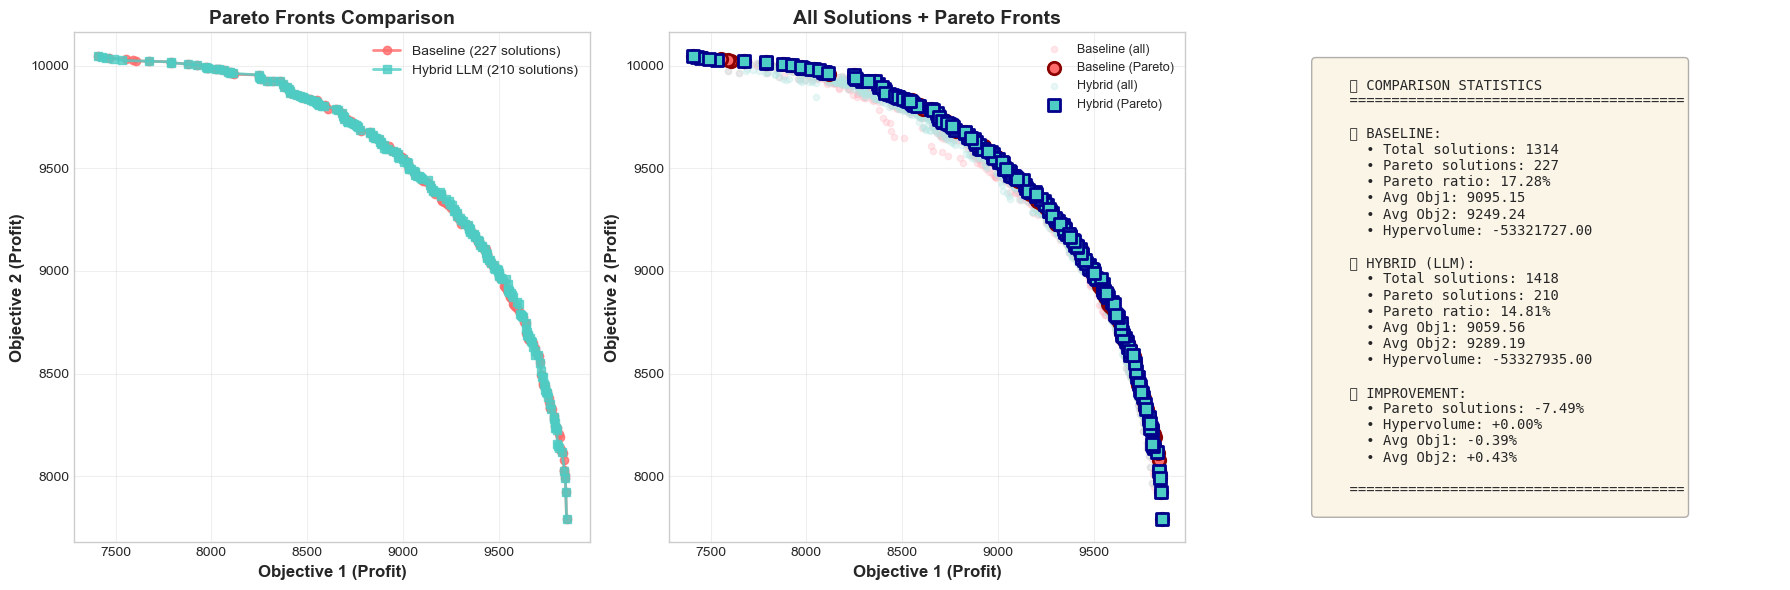


📊 QUICK SUMMARY:
Baseline Pareto: 227 solutions
Hybrid Pareto:   210 solutions
Improvement:     -7.49%
Hypervolume imp: +0.00%



In [13]:
# Cell: Visualization - Pareto Front Comparison

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

def load_points_from_file(filename):
    """Load all points from results file"""
    points = []
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        points.append([float(x) for x in line.split()])
                    except:
                        pass
    except FileNotFoundError:
        print(f"❌ File not found: {filename}")
        return []
    return points

def dominates(a, b):
    """Check if solution a dominates b (maximization)"""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_pareto_front(points):
    """Extract Pareto-optimal solutions"""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume_2d(pareto_front, reference_point):
    """Calculate hypervolume for 2D (approximation)"""
    if len(pareto_front) == 0:
        return 0.0
    
    # Sort by first objective (descending)
    sorted_front = sorted(pareto_front, key=lambda x: x[0], reverse=True)
    
    hypervolume = 0.0
    prev_f1 = reference_point[0]
    
    for solution in sorted_front:
        f1, f2 = solution[0], solution[1]
        width = prev_f1 - f1
        height = f2 - reference_point[1]
        hypervolume += width * height
        prev_f1 = f1
    
    return hypervolume

def plot_pareto_comparison_2d(baseline_file, hybrid_file, title="Pareto Front Comparison"):
    """Plot 2D Pareto front comparison"""
    
    # Load data
    baseline_points = load_points_from_file(baseline_file)
    hybrid_points = load_points_from_file(hybrid_file)
    
    if not baseline_points or not hybrid_points:
        print("❌ Cannot load data files")
        return
    
    # Extract Pareto fronts
    baseline_pareto = get_pareto_front(baseline_points)
    hybrid_pareto = get_pareto_front(hybrid_points)
    
    # Convert to numpy arrays
    baseline_pareto = np.array(baseline_pareto)
    hybrid_pareto = np.array(hybrid_pareto)
    baseline_all = np.array(baseline_points)
    hybrid_all = np.array(hybrid_points)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(18, 6))
    
    # ========== SUBPLOT 1: Pareto Fronts Only ==========
    ax1 = fig.add_subplot(1, 3, 1)
    
    # Sort for line plotting
    baseline_sorted = baseline_pareto[baseline_pareto[:, 0].argsort()]
    hybrid_sorted = hybrid_pareto[hybrid_pareto[:, 0].argsort()]
    
    ax1.plot(baseline_sorted[:, 0], baseline_sorted[:, 1], 
             'o-', color='#FF6B6B', linewidth=2, markersize=6, 
             label=f'Baseline ({len(baseline_pareto)} solutions)', alpha=0.8)
    ax1.plot(hybrid_sorted[:, 0], hybrid_sorted[:, 1], 
             's-', color='#4ECDC4', linewidth=2, markersize=6, 
             label=f'Hybrid LLM ({len(hybrid_pareto)} solutions)', alpha=0.8)
    
    ax1.set_xlabel('Objective 1 (Profit)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Objective 2 (Profit)', fontsize=12, fontweight='bold')
    ax1.set_title('Pareto Fronts Comparison', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # ========== SUBPLOT 2: All Solutions ==========
    ax2 = fig.add_subplot(1, 3, 2)
    
    ax2.scatter(baseline_all[:, 0], baseline_all[:, 1], 
                c='#FFB6C1', s=20, alpha=0.3, label='Baseline (all)')
    ax2.scatter(baseline_pareto[:, 0], baseline_pareto[:, 1], 
                c='#FF6B6B', s=80, marker='o', edgecolors='darkred', 
                linewidths=2, label='Baseline (Pareto)', zorder=5)
    
    ax2.scatter(hybrid_all[:, 0], hybrid_all[:, 1], 
                c='#B4E7E3', s=20, alpha=0.3, label='Hybrid (all)')
    ax2.scatter(hybrid_pareto[:, 0], hybrid_pareto[:, 1], 
                c='#4ECDC4', s=80, marker='s', edgecolors='darkblue', 
                linewidths=2, label='Hybrid (Pareto)', zorder=5)
    
    ax2.set_xlabel('Objective 1 (Profit)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Objective 2 (Profit)', fontsize=12, fontweight='bold')
    ax2.set_title('All Solutions + Pareto Fronts', fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # ========== SUBPLOT 3: Statistics ==========
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.axis('off')
    
    # Calculate metrics
    ref_point = [0, 0]  # For hypervolume (nadir point)
    hv_baseline = calculate_hypervolume_2d(baseline_pareto.tolist(), ref_point)
    hv_hybrid = calculate_hypervolume_2d(hybrid_pareto.tolist(), ref_point)
    hv_improvement = ((hv_hybrid - hv_baseline) / hv_baseline * 100) if hv_baseline > 0 else 0
    
    pareto_improvement = ((len(hybrid_pareto) - len(baseline_pareto)) / len(baseline_pareto) * 100)
    
    # Average objectives
    baseline_avg = baseline_pareto.mean(axis=0)
    hybrid_avg = hybrid_pareto.mean(axis=0)
    
    stats_text = f"""
    📊 COMPARISON STATISTICS
    {'='*40}
    
    🔴 BASELINE:
      • Total solutions: {len(baseline_points)}
      • Pareto solutions: {len(baseline_pareto)}
      • Pareto ratio: {len(baseline_pareto)/len(baseline_points)*100:.2f}%
      • Avg Obj1: {baseline_avg[0]:.2f}
      • Avg Obj2: {baseline_avg[1]:.2f}
      • Hypervolume: {hv_baseline:.2f}
    
    🔵 HYBRID (LLM):
      • Total solutions: {len(hybrid_points)}
      • Pareto solutions: {len(hybrid_pareto)}
      • Pareto ratio: {len(hybrid_pareto)/len(hybrid_points)*100:.2f}%
      • Avg Obj1: {hybrid_avg[0]:.2f}
      • Avg Obj2: {hybrid_avg[1]:.2f}
      • Hypervolume: {hv_hybrid:.2f}
    
    📈 IMPROVEMENT:
      • Pareto solutions: {pareto_improvement:+.2f}%
      • Hypervolume: {hv_improvement:+.2f}%
      • Avg Obj1: {(hybrid_avg[0]-baseline_avg[0])/baseline_avg[0]*100:+.2f}%
      • Avg Obj2: {(hybrid_avg[1]-baseline_avg[1])/baseline_avg[1]*100:+.2f}%
    
    {'='*40}
    """
    
    ax3.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
             verticalalignment='center', bbox=dict(boxstyle='round', 
             facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig('pareto_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Plot saved as 'pareto_comparison.png'")
    plt.show()
    
    # Return metrics for further analysis
    return {
        'baseline': {
            'total': len(baseline_points),
            'pareto': len(baseline_pareto),
            'hypervolume': hv_baseline,
            'avg': baseline_avg
        },
        'hybrid': {
            'total': len(hybrid_points),
            'pareto': len(hybrid_pareto),
            'hypervolume': hv_hybrid,
            'avg': hybrid_avg
        },
        'improvement': {
            'pareto_pct': pareto_improvement,
            'hypervolume_pct': hv_improvement
        }
    }


def plot_pareto_comparison_3d(baseline_file, hybrid_file):
    """Plot 3D Pareto front comparison (for 3-objective problems)"""
    
    baseline_points = load_points_from_file(baseline_file)
    hybrid_points = load_points_from_file(hybrid_file)
    
    if not baseline_points or not hybrid_points:
        print("❌ Cannot load data files")
        return
    
    if len(baseline_points[0]) != 3:
        print("⚠️  This function is for 3-objective problems only")
        return
    
    baseline_pareto = np.array(get_pareto_front(baseline_points))
    hybrid_pareto = np.array(get_pareto_front(hybrid_points))
    
    fig = plt.figure(figsize=(14, 6))
    
    # Subplot 1: Baseline
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(baseline_pareto[:, 0], baseline_pareto[:, 1], baseline_pareto[:, 2],
                c='#FF6B6B', s=50, alpha=0.6, edgecolors='darkred', linewidths=1.5)
    ax1.set_xlabel('Objective 1', fontweight='bold')
    ax1.set_ylabel('Objective 2', fontweight='bold')
    ax1.set_zlabel('Objective 3', fontweight='bold')
    ax1.set_title(f'Baseline Pareto Front\n({len(baseline_pareto)} solutions)', fontweight='bold')
    
    # Subplot 2: Hybrid
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(hybrid_pareto[:, 0], hybrid_pareto[:, 1], hybrid_pareto[:, 2],
                c='#4ECDC4', s=50, alpha=0.6, edgecolors='darkblue', linewidths=1.5)
    ax2.set_xlabel('Objective 1', fontweight='bold')
    ax2.set_ylabel('Objective 2', fontweight='bold')
    ax2.set_zlabel('Objective 3', fontweight='bold')
    ax2.set_title(f'Hybrid LLM Pareto Front\n({len(hybrid_pareto)} solutions)', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('pareto_comparison_3d.png', dpi=300, bbox_inches='tight')
    print("✅ 3D plot saved as 'pareto_comparison_3d.png'")
    plt.show()


# ========== USAGE EXAMPLES ==========

if __name__ == "__main__":
    print("VISUALIZING PARETO FRONTS")
    
    # For 2-objective problems
    metrics = plot_pareto_comparison_2d(
        OUTPUT_BASELINE, 
        OUTPUT_HYBRID,
        title="Baseline vs Hybrid LLM"
    )
    
    # Print summary
    if metrics:
        print(f"\n{'='*50}")
        print(f"📊 QUICK SUMMARY:")
        print(f"{'='*50}")
        print(f"Baseline Pareto: {metrics['baseline']['pareto']} solutions")
        print(f"Hybrid Pareto:   {metrics['hybrid']['pareto']} solutions")
        print(f"Improvement:     {metrics['improvement']['pareto_pct']:+.2f}%")
        print(f"Hypervolume imp: {metrics['improvement']['hypervolume_pct']:+.2f}%")
        print(f"{'='*50}\n")
    
    # Uncomment for 3-objective problems:
    # plot_pareto_comparison_3d(OUTPUT_BASELINE, OUTPUT_HYBRID)

📊 Generating visualization for 250 items, 2 objectives...
✅ Plot saved as 250 items, 2 objectives_pareto_comparison.png


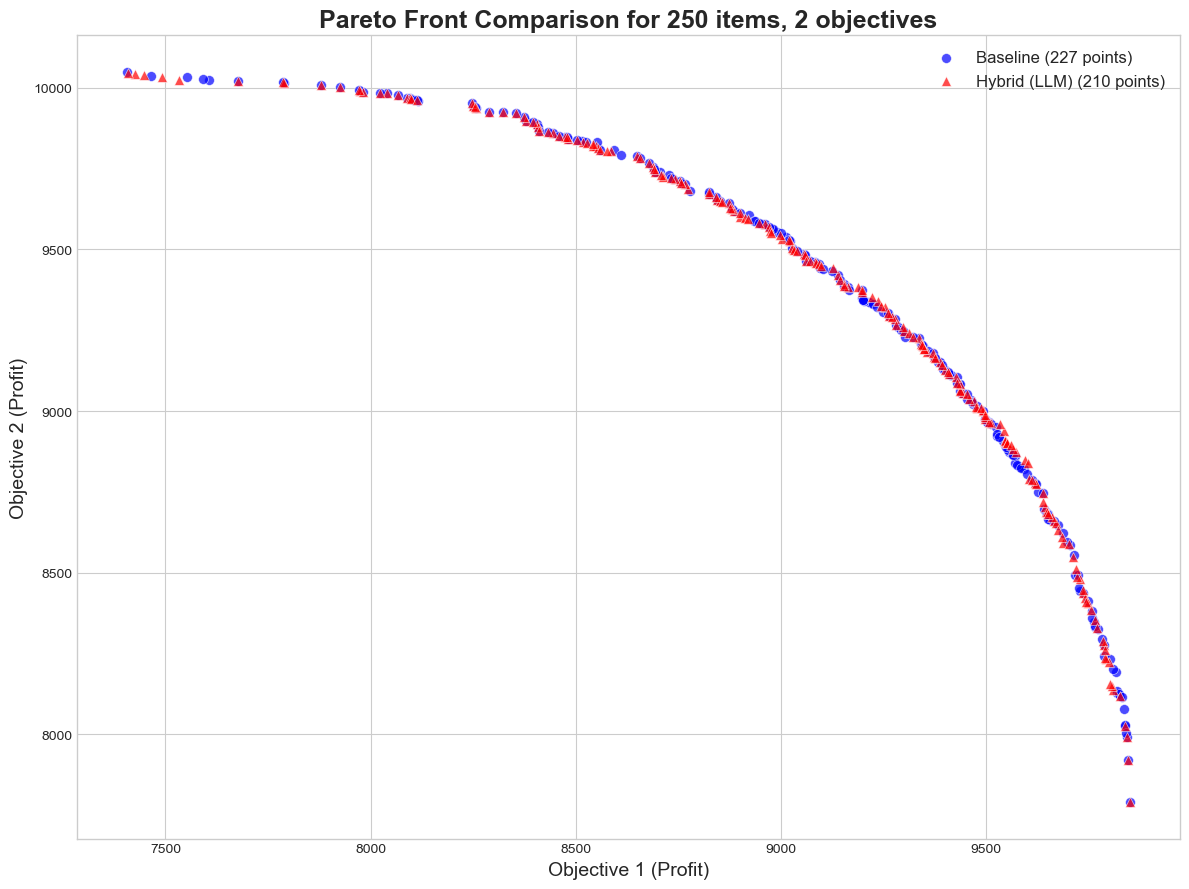

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- Helper Functions (same as before) ---
def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extracts the non-dominated points from a list of points."""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def load_and_parse_results(filename):
    """Loads a results file and parses it into a list of points."""
    points = []
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line:  # Skip empty lines
                    try:
                        # Split the line by whitespace and convert to float
                        point = [float(x) for x in line.split()]
                        if len(point) == 2: # Ensure it's a 2-objective point
                            points.append(point)
                    except ValueError:
                        print(f"Warning: Could not parse line: '{line}' in {filename}")
    except FileNotFoundError:
        print(f"Error: File not found at {filename}")
        return None
    return points

def plot_pareto_comparison(baseline_file, hybrid_file, instance_name="250.2"):
    """
    Generates a comparison plot of the Pareto fronts from two result files.
    """
    print(f"📊 Generating visualization for {instance_name}...")

    # 1. Load the raw data from both files
    baseline_points = load_and_parse_results(baseline_file)
    hybrid_points = load_and_parse_results(hybrid_file)

    if baseline_points is None or hybrid_points is None:
        print("❌ Cannot generate plot due to missing or corrupt files.")
        return

    # 2. Extract the true Pareto-optimal points from each dataset
    baseline_pareto = get_true_pareto_front(baseline_points)
    hybrid_pareto = get_true_pareto_front(hybrid_points)

    # 3. Prepare data for plotting
    if not baseline_pareto or not hybrid_pareto:
        print("❌ One of the result files is empty. Cannot plot.")
        return
        
    baseline_x, baseline_y = zip(*baseline_pareto)
    hybrid_x, hybrid_y = zip(*hybrid_pareto)

    # 4. Create the plot
    plt.style.use('seaborn-v0_8-whitegrid') # Use a clean, professional style
    plt.figure(figsize=(12, 9))

    # Plot the baseline Pareto front
    plt.scatter(baseline_x, baseline_y, 
                color='blue', 
                label=f'Baseline ({len(baseline_pareto)} points)', 
                alpha=0.7, 
                s=50, # Marker size
                edgecolors='w', # White edge for markers
                linewidth=0.5)

    # Plot the hybrid Pareto front
    plt.scatter(hybrid_x, hybrid_y, 
                color='red', 
                label=f'Hybrid (LLM) ({len(hybrid_pareto)} points)', 
                alpha=0.7, 
                s=50,
                marker='^', # Use a different marker shape
                edgecolors='w',
                linewidth=0.5)

    # 5. Add labels, title, and legend
    plt.xlabel("Objective 1 (Profit)", fontsize=14)
    plt.ylabel("Objective 2 (Profit)", fontsize=14)
    plt.title(f"Pareto Front Comparison for {instance_name}", fontsize=18, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True) # Ensure grid is on
    plt.tight_layout() # Adjust plot to ensure everything fits without overlapping

    # 6. Save and show the plot
    output_filename = f"{instance_name}_pareto_comparison.png"
    plt.savefig(output_filename, dpi=300) # Save as a high-resolution image
    print(f"✅ Plot saved as {output_filename}")
    plt.show()

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # --- Configuration ---
    # Make sure these filenames match the ones from your experiment controller
    BASELINE_FILE = "250_2obj_BASELINE.txt"
    HYBRID_FILE = "250_2obj_HYBRID.txt"
    INSTANCE_NAME = "250 items, 2 objectives"

    # Run the visualization
    plot_pareto_comparison(BASELINE_FILE, HYBRID_FILE, INSTANCE_NAME)
